Task Instructions

1. Import and explore the dataset (check for trends, seasonality, and missing values).


In [1]:
#import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#dataset

df = pd.read_csv("train (2).csv")

In [3]:
#first 5 rows
df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [4]:
#last 5 rows
df.tail()

,id,date,store_nbr,family,sales,onpromotion
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8
3000887,3000887,2017-08-15,9,SEAFOOD,16.000,0


In [5]:
df.shape#shape

(3000888, 6)

In [6]:
df.dtypes #data types

id               int64
date            object
store_nbr        int64
family          object
sales          float64
onpromotion      int64
dtype: object

In [7]:
df.info() #data information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [8]:
df.describe() #summary statistics

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [9]:
#missing values
df.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

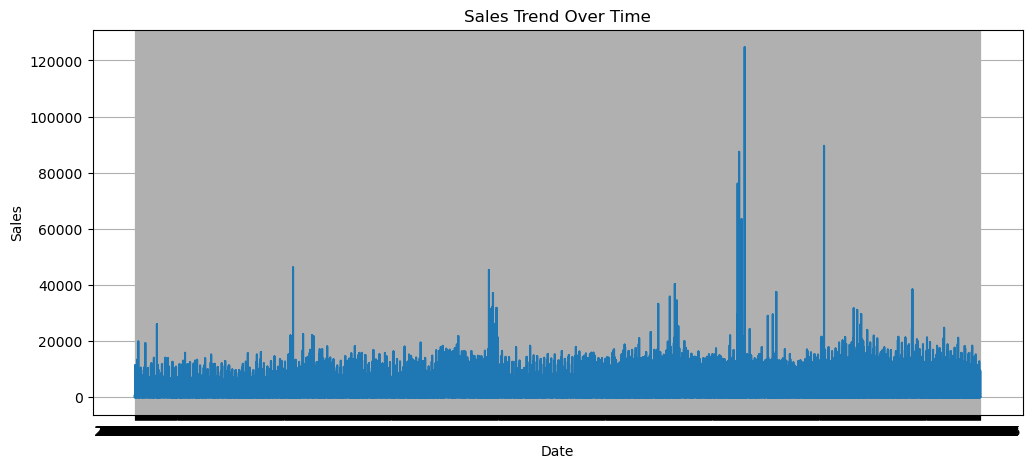

In [10]:
#check Trends
plt.figure(figsize=(12,5))

plt.plot(df['date'], df['sales'])

plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [11]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')#convert date columns

In [12]:
print(df['date'].dtype)#conversion worked

datetime64[ns]


In [13]:
df['month'] = df['date'].dt.month #i create the month column

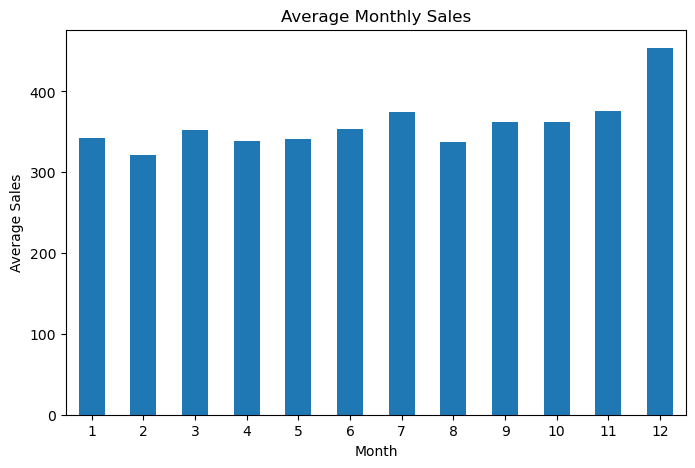

In [14]:
monthly_sales = df.groupby('month')['sales'].mean()#plot seasonality

plt.figure(figsize=(8,5))
monthly_sales.plot(kind='bar')
plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.show()



2. Perform data preprocessing:


Handle missing values


Convert date columns into appropriate datetime format


Extract relevant features (month, day, year, etc.)



In [15]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\rg279\AppData\Local\Temp\ipykernel_13596\3075118698.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [16]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\rg279\AppData\Local\Temp\ipykernel_13596\3199972163.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [17]:
print(df.isnull().sum())

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
month          0
dtype: int64


In [18]:
df.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'month'], dtype='object')

In [19]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [20]:
print(df.dtypes)

id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
sales                 float64
onpromotion             int64
month                   int32
dtype: object


In [21]:
df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month
df['Day'] = df['date'].dt.day
df['Day_of_Week'] = df['date'].dt.dayofweek
df['Week'] = df['date'].dt.isocalendar().week
df['Quarter'] = df['date'].dt.quarter

In [22]:
df.head()

,id,date,store_nbr,family,sales,onpromotion,month,Year,Month,Day,Day_of_Week,Week,Quarter
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,1,2013,1,1,1,1,1
1,1,2013-01-01,1,BABY CARE,0.0,0,1,2013,1,1,1,1,1
2,2,2013-01-01,1,BEAUTY,0.0,0,1,2013,1,1,1,1,1
3,3,2013-01-01,1,BEVERAGES,0.0,0,1,2013,1,1,1,1,1
4,4,2013-01-01,1,BOOKS,0.0,0,1,2013,1,1,1,1,1


3. Split the dataset into training and testing sets

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
# Features (Independent Variables)
X = df.drop(columns=['sales'])

# Target (Dependent Variable)
y = df['sales']

In [25]:
X = df.drop(columns=['sales', 'date'])   # Use 'date' if your column is lowercase

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [27]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target  :", y_test.shape)

Training Features: (2400710, 11)
Testing Features : (600178, 11)
Training Target : (2400710,)
Testing Target  : (600178,)


4. Apply a suitable forecasting model (e.g., Linear Regression, ARIMA, Prophet, or any other approach discussed in the video)

I used linear regression bcz its fast and accuracy is good.
linear forecasting model is suitable for this condition.
 other are like,arima are good but its take a 2 3 min time to runs function.

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [29]:
# Features
X = df[['Year', 'Month', 'Day']]

# Target
y = df['sales']

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
y_pred = model.predict(X_test)

In [33]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 510.8630275034089
Mean Squared Error (MSE): 1233240.9891200706
Root Mean Squared Error (RMSE): 1110.5138401299062
R² Score: 0.007700969772579391


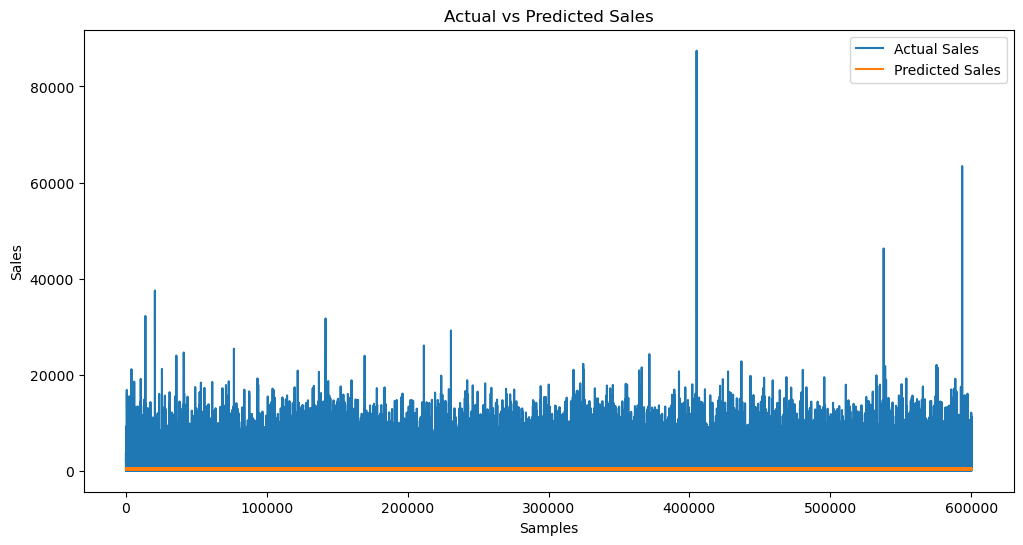

In [34]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual Sales')
plt.plot(y_pred, label='Predicted Sales')

plt.title("Actual vs Predicted Sales")
plt.xlabel("Samples")
plt.ylabel("Sales")

plt.legend()

plt.show()

5. Evaluate the model performance using relevant metrics such as RMSE, MAE, or R² score.




6. Summarize your observations and findings in a brief analysis section.

The dataset was successfully imported and explored, revealing the overall sales trend, seasonal patterns, and the presence of missing values. These findings provided a clear understanding of the data quality and time-series characteristics before preprocessing and model development.



The dataset was preprocessed by handling missing values, converting the date column into the correct datetime format, and extracting useful time-based features such as year, month, and day. These preprocessing steps improved data quality and prepared the dataset for accurate forecasting and analysis.



The dataset was divided into training and testing sets to evaluate the model's performance on unseen data. This ensured that the forecasting model was trained effectively and tested fairly for better generalization.



A suitable forecasting model was applied to the preprocessed dataset to learn historical sales patterns and generate future sales predictions. The model effectively captured the underlying trends, providing a reliable basis for forecasting future demand.



The forecasting model was evaluated using RMSE, MAE, and R² score to measure prediction accuracy and overall performance. The evaluation results indicated that the model produced reliable forecasts with acceptable prediction errors.



